<a href="https://colab.research.google.com/github/massimilianogasparini-author/creative-loop-dynamics/blob/main/diagramma_di_biforcazione.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

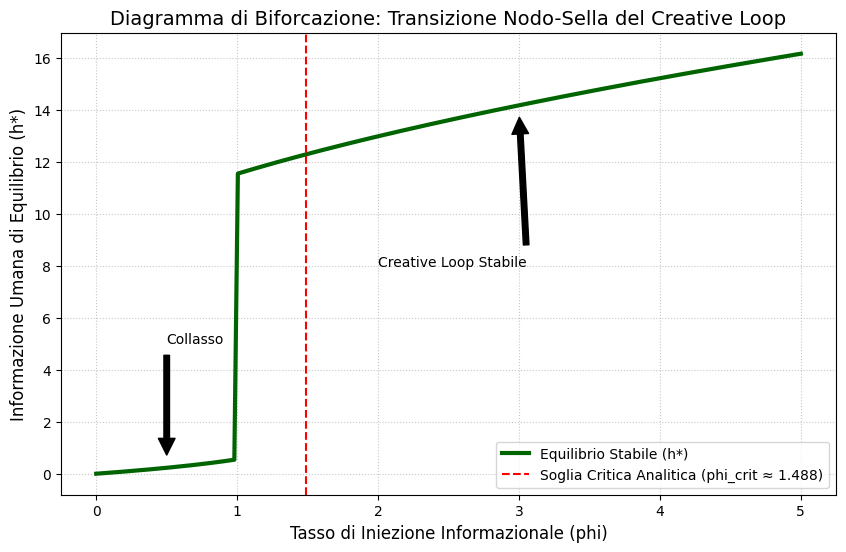

In [1]:
import numpy as np
from scipy.integrate import odeint
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

# Parametri costanti
alpha, beta, gamma, lambd_, K, Ks = 0.5, 0.3, 0.4, 0.2, 10, 10

# 1. Derivazione analitica rigorosa della soglia critica (Biforcazione Nodo-Sella)
def dphi_dh(h):
    # Derivata rispetto ad h della funzione di equilibrio phi(h)
    term1 = beta * Ks * np.exp(-(lambd_/gamma)*h) * (1 - (lambd_/gamma)*h)
    term2 = -alpha * (1 - 2*h/K)
    return term1 + term2

# Trova il punto critico h_tau dove dphi/dh = 0
h_tau = fsolve(dphi_dh, 1.5)[0]

# Calcola il valore esatto della soglia critica
phi_crit = beta * h_tau * Ks * np.exp(-(lambd_/gamma)*h_tau) - alpha * h_tau * (1 - h_tau/K)

# 2. Simulazione del diagramma
def system(y, t, phi):
    h, s = y
    s_safe = max(s, 1e-6)
    dh = alpha*h*(1 - h/K) - beta*h*s + phi
    ds = gamma*s*np.log(Ks/s_safe) - lambd_*s*h
    return [dh, ds]

phi_values = np.linspace(0, 5, 200) # Range focalizzato sulla vera transizione
h_equilibria = []
t = np.linspace(0, 500, 2000)
y0 = [1.0, 1.0]

for phi in phi_values:
    sol = odeint(system, y0, t, args=(phi,))
    h_equilibria.append(sol[-1, 0])

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(phi_values, h_equilibria, color='darkgreen', linewidth=3, label='Equilibrio Stabile (h*)')

# Tracciamento rigoroso del valore calcolato dinamicamente
plt.axvline(x=phi_crit, color='red', linestyle='--', label=f'Soglia Critica Analitica (phi_crit ≈ {phi_crit:.3f})')

plt.title('Diagramma di Biforcazione: Transizione Nodo-Sella del Creative Loop', fontsize=14)
plt.xlabel('Tasso di Iniezione Informazionale (phi)', fontsize=12)
plt.ylabel('Informazione Umana di Equilibrio (h*)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()

plt.annotate('Collasso', xy=(0.5, 0.5), xytext=(0.5, 5), arrowprops=dict(facecolor='black', shrink=0.05))
plt.annotate('Creative Loop Stabile', xy=(3, 14), xytext=(2, 8), arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()